In [6]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random
import matplotlib.pyplot as plt
import os
import neural_tangents as nt
from neural_tangents import stax
from infinitewidth import NtkInfiniteWidth

In [21]:
# we use the smallest values from the large experiments for N, D_IN, L
N = 6  # smallest number of data points
D_IN = 10  # smallest input dimension
L = 2  # smallest depth
M_VALUES = [10,20,30,40,50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]  # we vary network widths only
N_EXPERIMENTS = 10  # number of experiments per configuration
RANDOM_SEED = 20

In [22]:
PATH_TO_DATA = "experiments/data/ntk_convergence"
os.makedirs(PATH_TO_DATA, exist_ok=True)

In [23]:
def generate_data(key, n_samples, n_features):
    data = random.normal(key, (n_samples, n_features))
    norm = jnp.linalg.norm(data, axis=1, keepdims=True)
    return data / norm  # we normalize data points to unit norm

In [28]:
key_seed = RANDOM_SEED
print("Starting convergence analysis...")

spectral_radii_by_width = []
for M in M_VALUES:
    print(f"\nComputing for width M={M}...")
    
    spectral_radii = []
    for exp in range(N_EXPERIMENTS):
        key = jax.random.PRNGKey(key_seed)
        key_seed += 1
        
        data_key, model_key = random.split(key)  # we split key for data and model
        
        data = generate_data(data_key, N, D_IN)
        
        # we build the network architecture
        layers = []
        layers.append(stax.Dense(M, W_std=jnp.sqrt(2), b_std=0.0, parameterization='standard'))
        layers.append(stax.Relu())
        
        for _ in range(L-1):
            layers.append(stax.Dense(M, W_std=jnp.sqrt(2), b_std=0.0, parameterization='ntk'))
            layers.append(stax.Relu())
            
        layers.append(stax.Dense(1, W_std=jnp.sqrt(2), b_std=0.0, parameterization='ntk'))
        
        init_fn, apply_fn, _ = stax.serial(*layers)
        params = init_fn(model_key, data.shape)[1]
        ntk_fn = nt.empirical_ntk_fn(apply_fn)
        K = ntk_fn(data, None, params)  # we compute empirical NTK
        
        inf_model = NtkInfiniteWidth(n_layers=L, n_outputs=1)
        K_prime = inf_model.kernel_matrix(data)  # we compute infinite-width NTK
        
        correction = K - K_prime # we compute finite-width correction term
        eigenvalues = np.linalg.eigvalsh(correction)
        spectral_radius = np.max(np.abs(eigenvalues))  # we get spectral radius of correction
        spectral_radii.append(spectral_radius)
        
    mean_radius = np.mean(spectral_radii)
    std_radius = np.std(spectral_radii)
    spectral_radii_by_width.append((M, mean_radius, std_radius))
    print(f"Mean spectral radius: {mean_radius:.4f} ± {std_radius:.4f}")

Starting convergence analysis...

Computing for width M=10...
Mean spectral radius: 3.8495 ± 1.7410

Computing for width M=20...
Mean spectral radius: 2.4363 ± 0.6542

Computing for width M=30...
Mean spectral radius: 2.4800 ± 1.3475

Computing for width M=40...
Mean spectral radius: 2.1917 ± 1.0369

Computing for width M=50...
Mean spectral radius: 1.7259 ± 0.4688

Computing for width M=60...
Mean spectral radius: 1.8991 ± 0.7095

Computing for width M=70...
Mean spectral radius: 1.7261 ± 1.0833

Computing for width M=80...
Mean spectral radius: 1.8783 ± 0.6585

Computing for width M=90...
Mean spectral radius: 1.9176 ± 0.6377

Computing for width M=100...
Mean spectral radius: 2.0880 ± 1.0791

Computing for width M=200...
Mean spectral radius: 1.4541 ± 0.6930

Computing for width M=300...
Mean spectral radius: 1.4596 ± 0.7367

Computing for width M=400...
Mean spectral radius: 1.1992 ± 0.2868

Computing for width M=500...
Mean spectral radius: 1.2462 ± 0.5054

Computing for width M=6

KeyboardInterrupt: 

Array(0.13172868, dtype=float32)

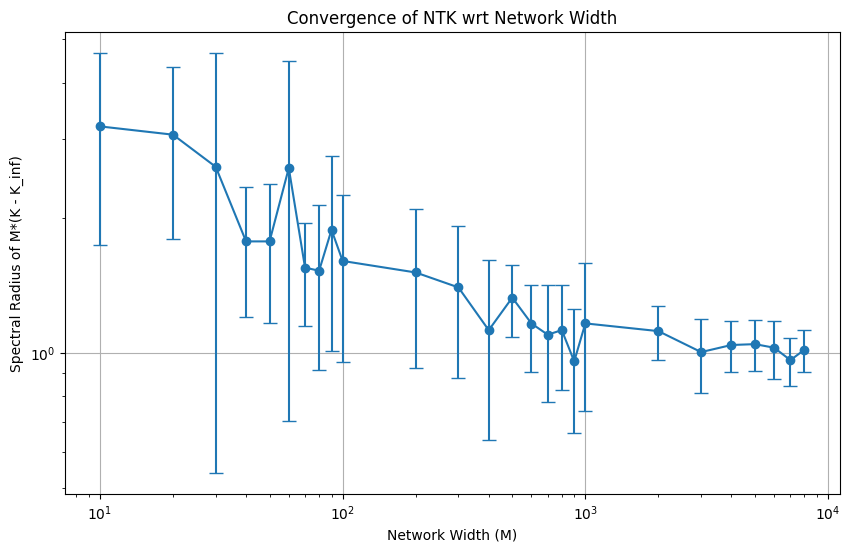

In [11]:
# we plot the results
widths = [x[0] for x in spectral_radii_by_width]
means = [x[1] for x in spectral_radii_by_width]
stds = [x[2] for x in spectral_radii_by_width]

plt.figure(figsize=(10, 6))
plt.errorbar(widths, means, yerr=stds, fmt='o-', capsize=5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Network Width (M)')
plt.ylabel('Spectral Radius of M*(K - K_inf)')
plt.title('Convergence of NTK wrt Network Width')
plt.grid(True)
plt.savefig(os.path.join(PATH_TO_DATA, 'ntk_convergence.png'))
#plt.close()

In [37]:
# we save the numerical results
np.save(os.path.join(PATH_TO_DATA, 'convergence_data.npy'), {
    'widths': widths,
    'means': means,
    'stds': stds,
    'N': N,
    'D_IN': D_IN,
    'L': L,
    'N_EXPERIMENTS': N_EXPERIMENTS,
    'RANDOM_SEED': RANDOM_SEED
})